In [30]:
import os
import json
from pathlib import Path

import numpy as np
from tensorflow.keras import layers, models
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [31]:

DATA_DIR = Path("../data/processed/augmented")
FIGURE_DIR = '../outputs/figures'
PLOTS_DIR = '../outputs/figures/plots'
MODEL_DIR = Path("../outputs/models")
OUTPUT_DIR = Path("../outputs")

ACTIVE_STAGE = "stage05"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)


In [32]:
SEED = 42
EPOCHS = 100
BATCH_SIZE = 4

# WEIGHT = 0.5
# WEIGHT = 1.0
# WEIGHT = 1.5
WEIGHT = 2.0

EARLY_STOPPING_PATIENCE = 15

tf.keras.utils.set_random_seed(SEED)

X_train = np.load(DATA_DIR / "XtrainAug.npy").astype(np.float32)
X_val = np.load(DATA_DIR / "Xval.npy").astype(np.float32)
Y_train = np.load(DATA_DIR / "YtrainAug.npy").astype(np.float32)
Y_val = np.load(DATA_DIR / "Yval.npy").astype(np.float32)

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype, "min/max:", X_train.min(), X_train.max())
print("X_val shape:", X_val.shape, "dtype:", X_val.dtype, "min/max:", X_val.min(), X_val.max())
print("Y_train shape:", Y_train.shape, "dtype:", Y_train.dtype, "min/max:", Y_train.min(), Y_train.max())
print("Y_val shape:", Y_val.shape, "dtype:", Y_val.dtype, "min/max:", Y_val.min(), Y_val.max())

print("Training foreground ratio:", float(Y_train.mean()))
print("Validation foreground ratio:", float(Y_val.mean()))

X_train shape: (384, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
X_val shape: (21, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Y_train shape: (384, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Y_val shape: (21, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Training foreground ratio: 0.2027888298034668
Validation foreground ratio: 0.2070094496011734


In [33]:
# simple 2-level no-skip baseline 
# inputs → encoder → bottleneck → decoder → sigmoid mask

def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(x)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="bubble_baseline")


In [34]:
def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) /
                (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(
        y_pred,
        tf.keras.backend.epsilon(),
        1 - tf.keras.backend.epsilon()
    )

    weights = y_true * WEIGHT + 1
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

    return tf.reduce_mean(weights * bce)

def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [35]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [36]:
model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coef, iou_coef]
)
model.summary()


Model: "bubble_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 256, 256, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 256, 256, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,401 (181.25 KB)

 Trainable params: 46,401 (181.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# checkpoint the best epoch, stop when validation stalls, lower LR on plateau

BEST_WEIGHTS_PATH = os.path.join(MODEL_DIR, f"{ACTIVE_STAGE}bubble_baseline_best.weights.h5")
HISTORY_CSV_PATH = os.path.join(OUTPUT_DIR, f"{ACTIVE_STAGE}baseline_training_history.csv")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_WEIGHTS_PATH),
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(str(HISTORY_CSV_PATH)),
]

In [38]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks
)

# all later evaluation must use the best checkpointed epoch, not the last one
model.load_weights(BEST_WEIGHTS_PATH)

Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_coef: 0.2820 - iou_coef: 0.1662 - loss: 1.6925
Epoch 1: val_dice_coef improved from None to 0.29268, saving model to ../outputs/models/stage05bubble_baseline_best.weights.h5

Epoch 1: finished saving model to ../outputs/models/stage05bubble_baseline_best.weights.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - dice_coef: 0.2835 - iou_coef: 0.1672 - loss: 1.6921 - val_dice_coef: 0.2927 - val_iou_coef: 0.1750 - val_loss: 1.6977 - learning_rate: 1.0000e-04
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - dice_coef: 0.2823 - iou_coef: 0.1663 - loss: 1.6828
Epoch 2: val_dice_coef improved from 0.29268 to 0.30000, saving model to ../outputs/models/stage05bubble_baseline_best.weights.h5

Epoch 2: finished saving model to ../outputs/models/stage05bubble_baseline_best.weights.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - dice_coef: 0.2860 - iou_coef: 0.1688 - loss: 1.6743 - val_dice_coef: 0.3000 - val_iou_coef: 0.1799 - val_loss: 

In [39]:
# MODEL_PATH = MODEL_DIR / "bubble_baseline.keras"
MODEL_PATH = os.path.join(MODEL_DIR, f"{ACTIVE_STAGE}bubble_baseline.keras")
HISTORY_PATH = os.path.join(OUTPUT_DIR, f"{ACTIVE_STAGE}baseline_training_history.json")

model.save(MODEL_PATH)
serializable_history = {
    name: [float(value) for value in values]
    for name, values in history.history.items()
}
with open(HISTORY_PATH, "w") as history_file:
    json.dump(serializable_history, history_file, indent=2)

print("Saved model to:", MODEL_PATH)
print("Saved training history to:", HISTORY_PATH)

Saved model to: ../outputs/models/stage05bubble_baseline.keras
Saved training history to: ../outputs/stage05baseline_training_history.json


In [40]:
# for previously trained model

if "model" not in globals():
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)


In [41]:
preds_val = model.predict(X_val)

print("Prediction min:", preds_val.min())
print("Prediction max:", preds_val.max())
print("Prediction mean:", preds_val.mean())
print("Ground truth foreground ratio:", Y_val.mean())

def dice_at_threshold(y_true, y_pred, threshold):
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    return (2 * intersection + 1) / (np.sum(y_true) + np.sum(y_pred_bin) + 1)

for t in np.arange(0.25, 0.50, 0.025):
    d = dice_at_threshold(Y_val, preds_val, t)
    fg = (preds_val > t).mean()
    print(f"Threshold {t:.3f} | Dice: {d:.4f} | Pred foreground: {fg:.4f}")
    
# for t in [0.2, 0.3, 0.4, 0.5]:
#     print(f"Foreground ratio at threshold {t}:", (preds_val > t).mean())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
Prediction min: 1.0918182e-16
Prediction max: 0.9973088
Prediction mean: 0.37611076
Ground truth foreground ratio: 0.20700945
Threshold 0.250 | Dice: 0.3804 | Pred foreground: 0.8588
Threshold 0.275 | Dice: 0.4046 | Pred foreground: 0.7465
Threshold 0.300 | Dice: 0.4312 | Pred foreground: 0.6208
Threshold 0.325 | Dice: 0.4418 | Pred foreground: 0.5347
Threshold 0.350 | Dice: 0.4454 | Pred foreground: 0.4695
Threshold 0.375 | Dice: 0.4458 | Pred foreground: 0.4157
Threshold 0.400 | Dice: 0.4443 | Pred foreground: 0.3705
Threshold 0.425 | Dice: 0.4406 | Pred foreground: 0.3302
Threshold 0.450 | Dice: 0.4371 | Pred foreground: 0.2934
Threshold 0.475 | Dice: 0.4312 | Pred foreground: 0.2590


In [42]:
thresholds = np.arange(0.05, 0.951, 0.025)
threshold_results = []

for threshold in thresholds:
    dice = dice_at_threshold(Y_val, preds_val, threshold)
    foreground_ratio = float((preds_val > threshold).mean())
    threshold_results.append(
        (float(threshold), float(dice), foreground_ratio)
    )
    print(
        f"Threshold {threshold:.3f} | Dice: {dice:.4f} | "
        f"Pred foreground: {foreground_ratio:.4f}"
    )

best_threshold, best_dice, best_foreground_ratio = max(
    threshold_results,
    key=lambda result: result[1]
)

threshold_summary = {
    "best_threshold": best_threshold,
    "validation_dice": best_dice,
    "predicted_foreground_ratio": best_foreground_ratio,
    "ground_truth_foreground_ratio": float(Y_val.mean()),
}
with (OUTPUT_DIR / "baseline_threshold_summary.json").open("w") as summary_file:
    json.dump(threshold_summary, summary_file, indent=2)

print("\nBest validation threshold:", best_threshold)
print("Best validation Dice:", best_dice)
print("Best foreground ratio:", best_foreground_ratio)


Threshold 0.050 | Dice: 0.3666 | Pred foreground: 0.9222
Threshold 0.075 | Dice: 0.3667 | Pred foreground: 0.9218
Threshold 0.100 | Dice: 0.3669 | Pred foreground: 0.9213
Threshold 0.125 | Dice: 0.3671 | Pred foreground: 0.9206
Threshold 0.150 | Dice: 0.3677 | Pred foreground: 0.9188
Threshold 0.175 | Dice: 0.3680 | Pred foreground: 0.9174
Threshold 0.200 | Dice: 0.3685 | Pred foreground: 0.9156
Threshold 0.225 | Dice: 0.3703 | Pred foreground: 0.9091
Threshold 0.250 | Dice: 0.3804 | Pred foreground: 0.8588
Threshold 0.275 | Dice: 0.4046 | Pred foreground: 0.7465
Threshold 0.300 | Dice: 0.4312 | Pred foreground: 0.6208
Threshold 0.325 | Dice: 0.4418 | Pred foreground: 0.5347
Threshold 0.350 | Dice: 0.4454 | Pred foreground: 0.4695
Threshold 0.375 | Dice: 0.4458 | Pred foreground: 0.4157
Threshold 0.400 | Dice: 0.4443 | Pred foreground: 0.3705
Threshold 0.425 | Dice: 0.4406 | Pred foreground: 0.3302
Threshold 0.450 | Dice: 0.4371 | Pred foreground: 0.2934
Threshold 0.475 | Dice: 0.4312 

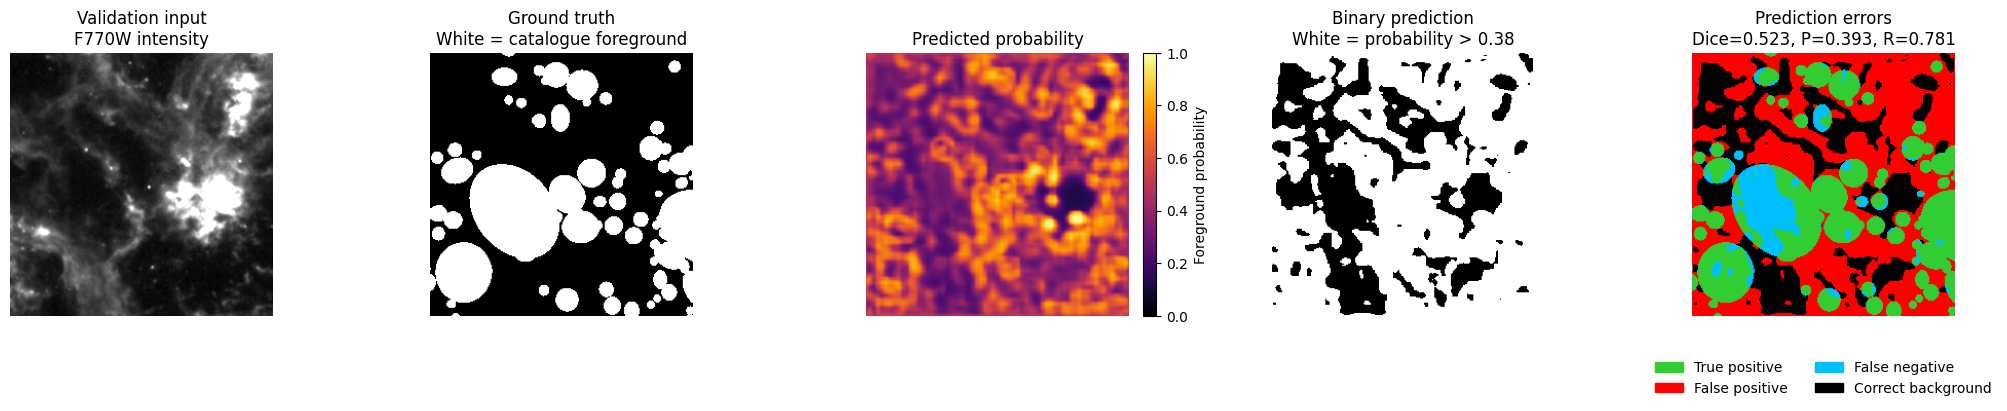

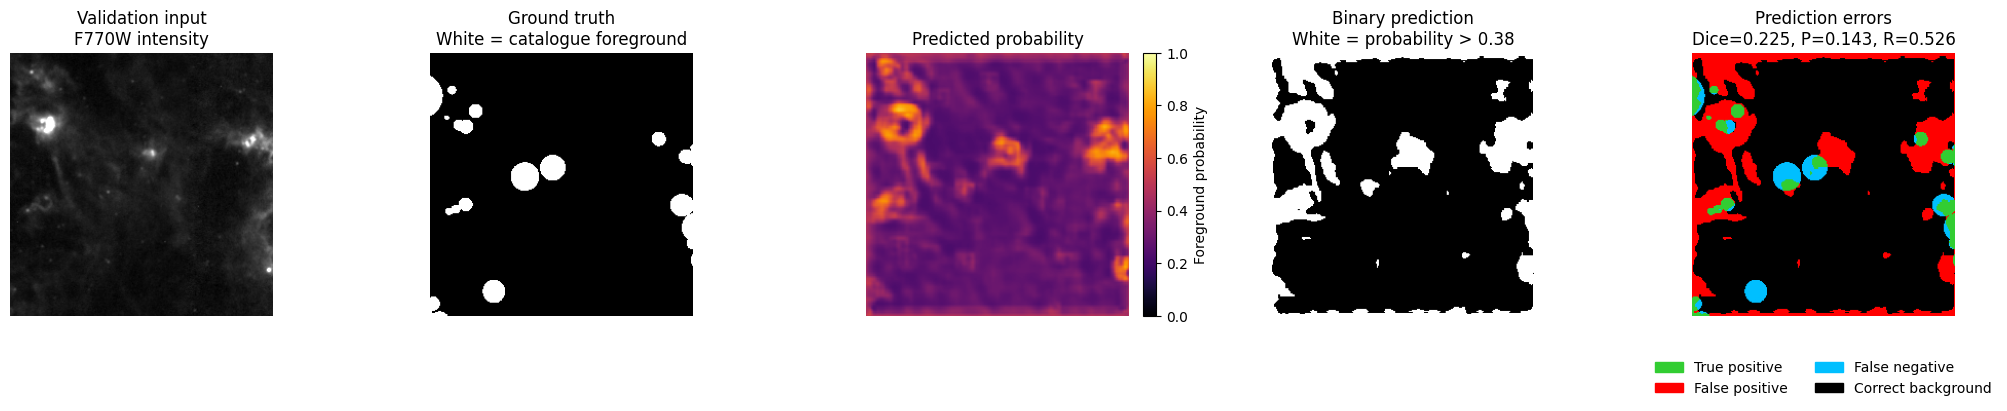

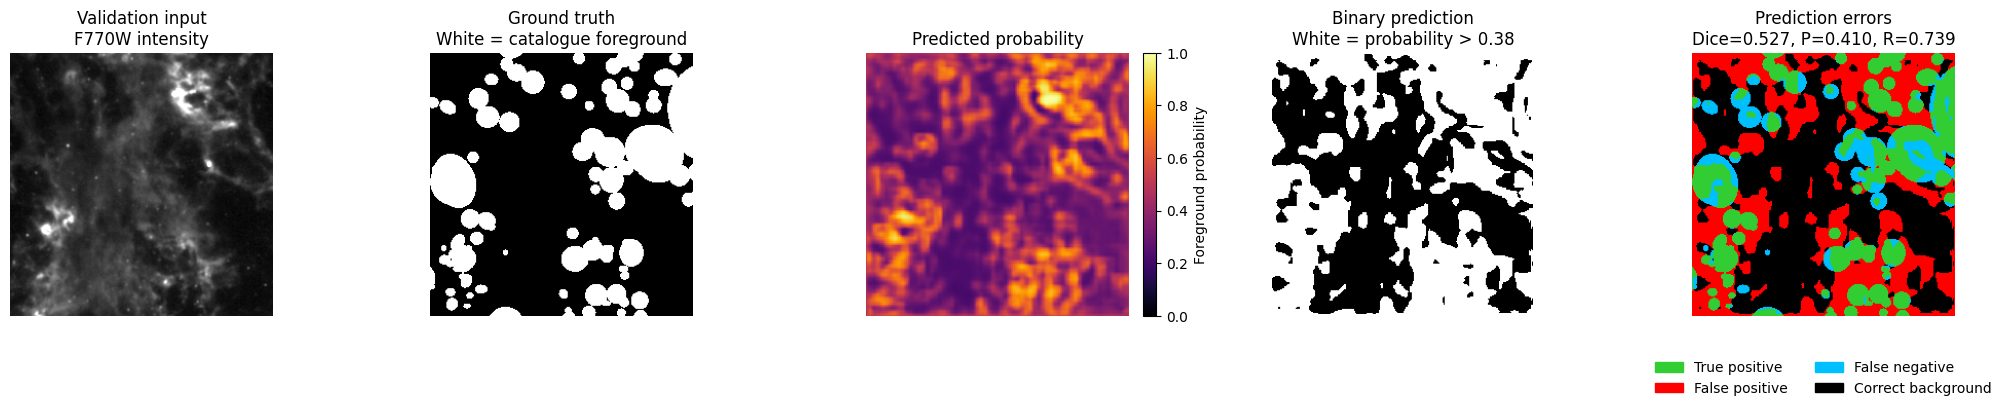

In [43]:
for idx in [0, 10, 20]:
    image = X_val[idx].squeeze()
    ground_truth = Y_val[idx].squeeze() > 0.5
    probability = preds_val[idx].squeeze()
    prediction = probability > best_threshold

    tp = ground_truth & prediction
    fp = ~ground_truth & prediction
    fn = ground_truth & ~prediction

    tp_count = tp.sum()
    fp_count = fp.sum()
    fn_count = fn.sum()

    precision = tp_count / (tp_count + fp_count + 1e-8)
    recall = tp_count / (tp_count + fn_count + 1e-8)
    dice = (
        2 * tp_count /
        (2 * tp_count + fp_count + fn_count + 1e-8)
    )

    # 0 = correct background
    # 1 = true positive
    # 2 = false positive
    # 3 = false negative
    comparison = np.zeros(ground_truth.shape, dtype=np.uint8)
    comparison[tp] = 1
    comparison[fp] = 2
    comparison[fn] = 3

    comparison_cmap = ListedColormap([
        "black",       # correct background
        "limegreen",   # true positive
        "red",         # false positive
        "deepskyblue"  # false negative
    ])

    fig, axes = plt.subplots(1, 5, figsize=(21, 4))

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Validation input\nF770W intensity")

    axes[1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1].set_title("Ground truth\nWhite = catalogue foreground")

    probability_plot = axes[2].imshow(
        probability,
        cmap="inferno",
        vmin=0,
        vmax=1
    )
    axes[2].set_title("Predicted probability")

    colorbar = fig.colorbar(
        probability_plot,
        ax=axes[2],
        fraction=0.046,
        pad=0.04
    )
    colorbar.set_label("Foreground probability")

    axes[3].imshow(
        prediction,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[3].set_title(
        f"Binary prediction\n"
        f"White = probability > {best_threshold:.2f}"
    )

    axes[4].imshow(
        comparison,
        cmap=comparison_cmap,
        vmin=0,
        vmax=3
    )
    axes[4].set_title(
        f"Prediction errors\n"
        f"Dice={dice:.3f}, P={precision:.3f}, R={recall:.3f}"
    )

    legend_items = [
        Patch(color="limegreen", label="True positive"),
        Patch(color="red", label="False positive"),
        Patch(color="deepskyblue", label="False negative"),
        Patch(color="black", label="Correct background")
    ]

    axes[4].legend(
        handles=legend_items,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.35),
        ncol=2,
        frameon=False
    )

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()

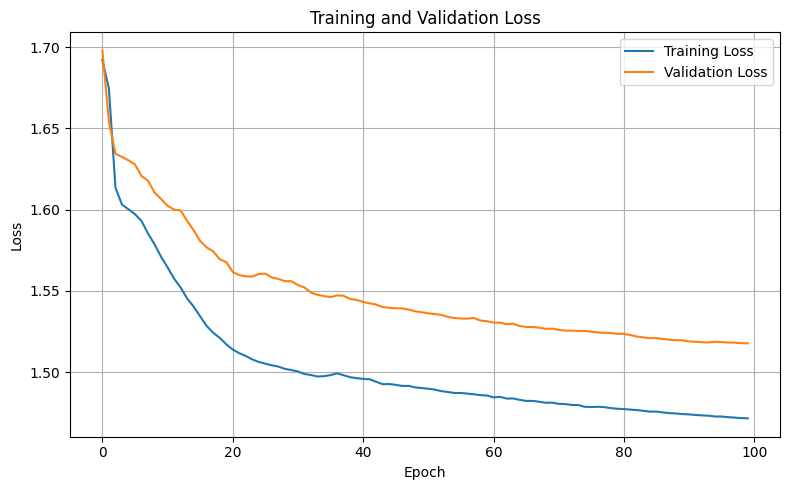

In [44]:
# Loss curves
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f"{ACTIVE_STAGE}baseline_loss_curve.png"), dpi=300)
plt.show()

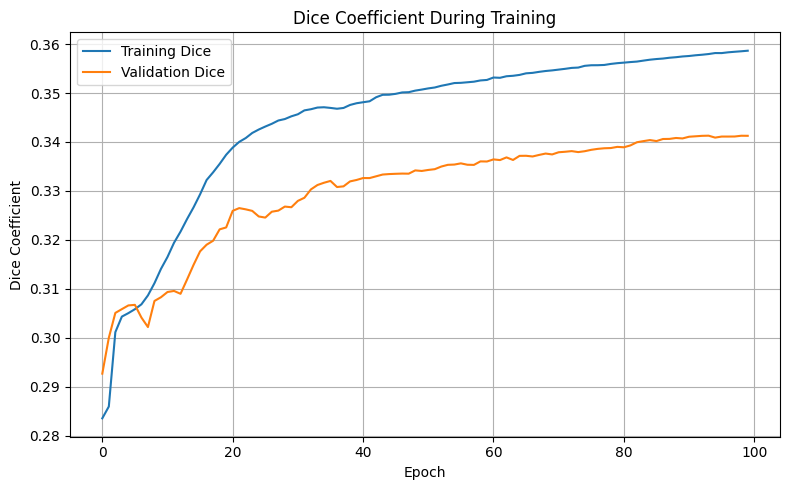

In [45]:
plt.figure(figsize=(8,5))
plt.plot(history.history['dice_coef'], label='Training Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')

plt.title('Dice Coefficient During Training')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, f"{ACTIVE_STAGE}baseline_dice_curve.png"), dpi=300)
plt.show()

## Comparison U-net baseline vs the U-Net model

Requires both evaluations to exist: run `perClassEvaluation.ipynb` twice with
the same `ACTIVE_STAGE` - once with `MODEL_TAG = "bubble_baseline"`, once with
`MODEL_TAG = "bubble_baseline"`.

In [48]:
# side-by-side per-class table; also written to outputs/predictions

import pandas as pd

EVAL_DIR = Path("../outputs/predictions")
UNET_EVAL = EVAL_DIR / f"{ACTIVE_STAGE}perClassEval.csv"
BASELINE_EVAL = EVAL_DIR / f"{ACTIVE_STAGE}baseline_perClassEval.csv"

for path in (UNET_EVAL, BASELINE_EVAL):
    assert path.exists(), (
        f"{path} missing - run perClassEvaluation.ipynb with the matching MODEL_TAG"
    )

SIZE_ORDER = ["edgeLarge", "giants", "large", "medium", "small", "tiny"]
METRICS = ["object_recall", "pixel_recall", "mean_coverage"]

unet = pd.read_csv(UNET_EVAL, index_col=0).reindex(SIZE_ORDER).dropna(how="all")
baseline = pd.read_csv(BASELINE_EVAL, index_col=0).reindex(SIZE_ORDER).dropna(how="all")

model_comparison = pd.DataFrame(index=unet.index)
model_comparison["n_bubbles"] = unet["n_bubbles"].astype(int)
for m in METRICS:
    model_comparison[f"{m}_unet"] = unet[m]
    model_comparison[f"{m}_baseline"] = baseline[m]
    model_comparison[f"{m}_delta"] = unet[m] - baseline[m]

print("global precision  unet:", round(unet["global_precision"].iloc[0], 3),
      "| baseline:", round(baseline["global_precision"].iloc[0], 3))
print("predicted blobs   unet:", int(unet["global_n_pred_blobs"].iloc[0]),
      f"({int(unet['global_n_spurious'].iloc[0])} spurious)",
      "| baseline:", int(baseline["global_n_pred_blobs"].iloc[0]),
      f"({int(baseline['global_n_spurious'].iloc[0])} spurious)")

model_comparison.to_csv(EVAL_DIR / f"{ACTIVE_STAGE}modelComparison.csv")
model_comparison.round(3)


global precision  unet: 0.737 | baseline: 0.537
predicted blobs   unet: 133 (35 spurious) | baseline: 523 (242 spurious)


,n_bubbles,object_recall_unet,object_recall_baseline,object_recall_delta,pixel_recall_unet,pixel_recall_baseline,pixel_recall_delta,mean_coverage_unet,mean_coverage_baseline,mean_coverage_delta
size_class,,,,,,,,,,
edgeLarge,26,0.615,0.231,0.385,0.622,0.332,0.290,0.620,0.349,0.271
giants,157,0.573,0.580,-0.006,0.582,0.496,0.086,0.578,0.548,0.030
large,155,0.613,0.800,-0.187,0.598,0.767,-0.169,0.593,0.759,-0.166
medium,95,0.611,0.621,-0.011,0.580,0.615,-0.036,0.566,0.612,-0.046
small,75,0.533,0.533,0.000,0.527,0.525,0.002,0.519,0.512,0.007
tiny,53,0.698,0.528,0.170,0.696,0.602,0.095,0.667,0.516,0.151


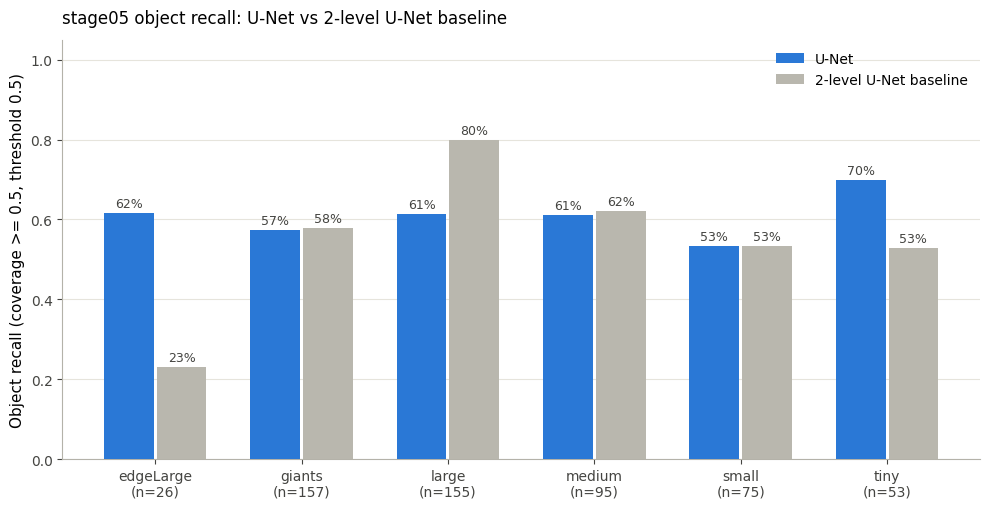

In [49]:
# object recall per size class: U-Net vs 2-level U-Net baseline
# color follows the model (blue = U-Net, recessive gray = baseline),
# same pairing as the chance-floor dumbbell plot

MODEL_COLORS = {"U-Net": "#2a78d6", "2-level U-Net baseline": "#b9b7ae"}
INK = "#444441"

classes = model_comparison.index.tolist()
xs = np.arange(len(classes))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 5.2))
for k, (name, series) in enumerate([("U-Net", unet["object_recall"]),
                                    ("2-level U-Net baseline", baseline["object_recall"])]):
    offsets = xs + (k - 0.5) * (width + 0.02)
    ax.bar(offsets, series.values, width=width,
           color=MODEL_COLORS[name], label=name, zorder=3)
    for x, v in zip(offsets, series.values):
        ax.text(x, v + 0.015, f"{v:.0%}", ha="center", fontsize=9, color=INK)

ax.set_xticks(xs)
ax.set_xticklabels([f"{c}\n(n={int(model_comparison.loc[c, 'n_bubbles'])})"
                    for c in classes], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Object recall (coverage >= 0.5, threshold 0.5)", fontsize=11)
ax.set_title(f"{ACTIVE_STAGE} object recall: U-Net vs 2-level U-Net baseline",
             fontsize=12, loc="left", pad=12)
ax.legend(frameon=False, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#b4b2a9")
ax.tick_params(colors=INK)
ax.grid(axis="y", color="#e6e4dc", lw=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f"{ACTIVE_STAGE}baselineComparison.png"),
            dpi=300, bbox_inches="tight")
plt.show()
